# GDP All Models Test Compare

This notebook compares the main GDP models across:
- OLS
- Ridge
- Elastic Net
- Random Forest
- XGBoost

Important comparison rule:
- Raw test metrics from each notebook are loaded first.
- Then a **fair common-sample comparison** is rebuilt from the saved test prediction files.
- The common-sample comparison is the one you should use for final benchmarking.


In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

OLS_METRICS_PATH = OUTPUT_DIR / "gdp_main_models_rebuilt_with_lag_metrics.csv"
OLS_TRAIN_PRED_PATH = OUTPUT_DIR / "gdp_main_models_rebuilt_with_lag_train_predictions.csv"
OLS_TEST_PRED_PATH = OUTPUT_DIR / "gdp_main_models_rebuilt_with_lag_test_predictions.csv"

TRAIN_CONTEXT_START_YEAR = 2000

SPEC_CONFIG = {
    "Model 1": {
        "ols_name": "Model 1 - Baseline Dynamic",
        "files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_1_dynamic_test_predictions.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_1_dynamic_test_predictions.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_1_test_predictions.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_1_test_predictions.csv",
        },
        "metric_files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_1_dynamic_metrics.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_1_dynamic_metrics.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_1_metrics.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_1_metrics.csv",
        },
    },
    "Model 2": {
        "ols_name": "Model 2 - Extended Dynamic",
        "files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_2_dynamic_test_predictions.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_2_dynamic_test_predictions.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_2_test_predictions.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_2_test_predictions.csv",
        },
        "metric_files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_2_dynamic_metrics.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_2_dynamic_metrics.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_2_metrics.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_2_metrics.csv",
        },
    },
    "Model 3": {
        "ols_name": "Model 3 - Full Dynamic",
        "files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_3_dynamic_test_predictions.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_3_dynamic_test_predictions.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_3_test_predictions.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_3_test_predictions.csv",
        },
        "metric_files": {
            "Ridge": OUTPUT_DIR / "gdp_ridge_model_3_dynamic_metrics.csv",
            "Elastic Net": OUTPUT_DIR / "gdp_elastic_net_model_3_dynamic_metrics.csv",
            "Random Forest": OUTPUT_DIR / "gdp_random_forest_model_3_metrics.csv",
            "XGBoost": OUTPUT_DIR / "gdp_xgboost_model_3_metrics.csv",
        },
    },
}

ALGORITHM_ORDER = ["OLS", "Ridge", "Elastic Net", "Random Forest", "XGBoost"]
SPEC_ORDER = ["Model 1", "Model 2", "Model 3"]
JOIN_COLS = ["country_code", "feature_year", "target_year"]

SAVE_RAW_METRICS_PATH = OUTPUT_DIR / "gdp_all_models_raw_test_metrics.csv"
SAVE_SAMPLE_SIZE_PATH = OUTPUT_DIR / "gdp_all_models_test_sample_sizes.csv"
SAVE_COMMON_METRICS_PATH = OUTPUT_DIR / "gdp_all_models_common_test_metrics.csv"
SAVE_BEST_BY_SPEC_PATH = OUTPUT_DIR / "gdp_all_models_best_algorithm_by_spec.csv"
SAVE_YEARLY_SUMMARY_PATH = OUTPUT_DIR / "gdp_all_models_common_test_yearly_summary.csv"
SAVE_CONTEXT_SUMMARY_PATH = OUTPUT_DIR / "gdp_all_models_train_test_context_yearly_summary.csv"
SAVE_COMMON_MODEL1_PATH = OUTPUT_DIR / "gdp_all_models_common_sample_model_1.csv"
SAVE_COMMON_MODEL2_PATH = OUTPUT_DIR / "gdp_all_models_common_sample_model_2.csv"
SAVE_COMMON_MODEL3_PATH = OUTPUT_DIR / "gdp_all_models_common_sample_model_3.csv"

print("Output dir:", OUTPUT_DIR)
print("Train context starts at:", TRAIN_CONTEXT_START_YEAR)
print("Notebook ready.")

Output dir: /Users/tonytony/Final Project/Data/Cleaned
Train context starts at: 2000
Notebook ready.


In [24]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def read_csv_checked(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)


def resolve_train_prediction_path(test_path):
    return Path(str(test_path).replace("_test_predictions.csv", "_train_predictions.csv"))


def normalize_prediction(df, algorithm, spec_label, split_name):
    keep_cols = [
        "country_name",
        "country_code",
        "wb_region",
        "feature_year",
        "target_year",
        "actual_gdp_next_year",
        "predicted_gdp_next_year",
    ]
    out = df[keep_cols].copy()
    out["algorithm"] = algorithm
    out["spec"] = spec_label
    out["split"] = split_name
    return out


def load_raw_test_metrics():
    rows = []

    ols_metrics = read_csv_checked(OLS_METRICS_PATH)
    ols_metrics = ols_metrics[
        (ols_metrics["split"] == "test") & (ols_metrics["scale"] == "level_gdp_usd")
    ].copy()

    spec_name_map = {
        "Model 1 - Baseline Dynamic": "Model 1",
        "Model 2 - Extended Dynamic": "Model 2",
        "Model 3 - Full Dynamic": "Model 3",
    }

    for _, row in ols_metrics.iterrows():
        rows.append(
            {
                "spec": spec_name_map[row["model"]],
                "algorithm": "OLS",
                "model": row["model"],
                "n_obs": row["n_obs"],
                "MAE": row["MAE"],
                "RMSE": row["RMSE"],
                "MAPE_pct": row["MAPE_pct"],
                "R_squared": row["R_squared"],
            }
        )

    for spec_label, cfg in SPEC_CONFIG.items():
        for algorithm, metric_path in cfg["metric_files"].items():
            df = read_csv_checked(metric_path)
            df = df[(df["split"] == "test") & (df["scale"] == "level_gdp_usd")].copy()
            row = df.iloc[0]
            rows.append(
                {
                    "spec": spec_label,
                    "algorithm": algorithm,
                    "model": row["model"],
                    "n_obs": row["n_obs"],
                    "MAE": row["MAE"],
                    "RMSE": row["RMSE"],
                    "MAPE_pct": row["MAPE_pct"],
                    "R_squared": row["R_squared"],
                }
            )

    out = pd.DataFrame(rows)
    out["spec"] = pd.Categorical(out["spec"], categories=SPEC_ORDER, ordered=True)
    out["algorithm"] = pd.Categorical(out["algorithm"], categories=ALGORITHM_ORDER, ordered=True)
    return out.sort_values(["spec", "algorithm"]).reset_index(drop=True)


def load_prediction_frames_for_spec(spec_label, split_name):
    cfg = SPEC_CONFIG[spec_label]
    frames = []

    ols_path = OLS_TRAIN_PRED_PATH if split_name == "train" else OLS_TEST_PRED_PATH
    ols_all = read_csv_checked(ols_path)
    ols_df = ols_all[ols_all["model"] == cfg["ols_name"]].copy()
    frames.append(normalize_prediction(ols_df, "OLS", spec_label, split_name))

    for algorithm, test_pred_path in cfg["files"].items():
        pred_path = resolve_train_prediction_path(test_pred_path) if split_name == "train" else test_pred_path
        df = read_csv_checked(pred_path)
        frames.append(normalize_prediction(df, algorithm, spec_label, split_name))

    return frames


def build_common_sample_wide(spec_label, split_name):
    frames = load_prediction_frames_for_spec(spec_label, split_name)

    first = frames[0].copy()
    first_pred_col = f"pred_{frames[0]['algorithm'].iloc[0].replace(' ', '_').lower()}"
    first = first.rename(columns={"predicted_gdp_next_year": first_pred_col})

    wide = first[
        [
            "country_name",
            "country_code",
            "wb_region",
            "feature_year",
            "target_year",
            "actual_gdp_next_year",
            first_pred_col,
        ]
    ].copy()

    for frame in frames[1:]:
        algorithm = frame["algorithm"].iloc[0]
        pred_col = f"pred_{algorithm.replace(' ', '_').lower()}"
        addon = frame[JOIN_COLS + ["predicted_gdp_next_year"]].rename(
            columns={"predicted_gdp_next_year": pred_col}
        )
        wide = wide.merge(addon, on=JOIN_COLS, how="inner")

    wide["spec"] = spec_label
    wide["split"] = split_name
    return wide


def compute_common_metrics(spec_label, wide_df):
    rows = []
    algorithm_map = {
        "OLS": "pred_ols",
        "Ridge": "pred_ridge",
        "Elastic Net": "pred_elastic_net",
        "Random Forest": "pred_random_forest",
        "XGBoost": "pred_xgboost",
    }
    for algorithm, pred_col in algorithm_map.items():
        metrics = regression_metrics(wide_df["actual_gdp_next_year"], wide_df[pred_col])
        rows.append(
            {
                "spec": spec_label,
                "algorithm": algorithm,
                "n_obs": len(wide_df),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def build_yearly_summary_long(spec_label, wide_df):
    algorithm_map = {
        "OLS": "pred_ols",
        "Ridge": "pred_ridge",
        "Elastic Net": "pred_elastic_net",
        "Random Forest": "pred_random_forest",
        "XGBoost": "pred_xgboost",
    }
    rows = []
    for target_year, year_df in wide_df.groupby("target_year", observed=False):
        rows.append(
            {
                "spec": spec_label,
                "algorithm": "Actual",
                "target_year": int(target_year),
                "mean_gdp": year_df["actual_gdp_next_year"].mean(),
            }
        )
        for algorithm, pred_col in algorithm_map.items():
            rows.append(
                {
                    "spec": spec_label,
                    "algorithm": algorithm,
                    "target_year": int(target_year),
                    "mean_gdp": year_df[pred_col].mean(),
                }
            )
    return pd.DataFrame(rows)


def build_train_test_context_long(spec_label, train_wide_df, test_wide_df, start_year=2000):
    algorithm_map = {
        "OLS": "pred_ols",
        "Ridge": "pred_ridge",
        "Elastic Net": "pred_elastic_net",
        "Random Forest": "pred_random_forest",
        "XGBoost": "pred_xgboost",
    }

    train_wide_df = train_wide_df[train_wide_df["target_year"] >= start_year].copy()
    test_wide_df = test_wide_df.copy()

    rows = []

    for split_name, wide_df in [("train", train_wide_df), ("test", test_wide_df)]:
        if wide_df.empty:
            continue

        actual_yearly = (
            wide_df.groupby("target_year", as_index=False)["actual_gdp_next_year"]
            .mean()
            .rename(columns={"target_year": "plot_year", "actual_gdp_next_year": "mean_gdp"})
        )
        actual_yearly["spec"] = spec_label
        actual_yearly["algorithm"] = "Actual"
        actual_yearly["segment"] = f"{split_name}_actual"
        rows.append(actual_yearly[["spec", "algorithm", "plot_year", "mean_gdp", "segment"]])

        for algorithm, pred_col in algorithm_map.items():
            pred_yearly = (
                wide_df.groupby("target_year", as_index=False)[pred_col]
                .mean()
                .rename(columns={"target_year": "plot_year", pred_col: "mean_gdp"})
            )
            pred_yearly["spec"] = spec_label
            pred_yearly["algorithm"] = algorithm
            pred_yearly["segment"] = f"{split_name}_prediction"
            rows.append(pred_yearly[["spec", "algorithm", "plot_year", "mean_gdp", "segment"]])

    out = pd.concat(rows, ignore_index=True)
    out["plot_year"] = out["plot_year"].astype(int)
    return out.sort_values(["spec", "algorithm", "plot_year"]).reset_index(drop=True)

In [25]:
raw_test_metrics_df = load_raw_test_metrics().round(4)

print("Raw test metrics loaded.")
display(raw_test_metrics_df)

sample_size_df = raw_test_metrics_df[["spec", "algorithm", "n_obs"]].copy()
sample_size_pivot = sample_size_df.pivot(index="algorithm", columns="spec", values="n_obs")

print("Raw test sample sizes by model family:")
display(sample_size_pivot)

raw_test_metrics_df.to_csv(SAVE_RAW_METRICS_PATH, index=False)
sample_size_df.to_csv(SAVE_SAMPLE_SIZE_PATH, index=False)

print("Saved:")
print("-", SAVE_RAW_METRICS_PATH)
print("-", SAVE_SAMPLE_SIZE_PATH)

Raw test metrics loaded.


,spec,algorithm,model,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 1,OLS,Model 1 - Baseline Dynamic,813,"1,498.1181","3,477.1503",9.1617,0.9766
1,Model 1,Ridge,Ridge Model 1 - Baseline Dynamic,1042,"1,703.8717","3,976.4164",9.3056,0.9821
2,Model 1,Elastic Net,Elastic Net Model 1 - Baseline Dynamic,1042,"1,702.1639","3,977.3740",9.3014,0.9821
3,Model 1,Random Forest,Random Forest Model 1 - Baseline Dynamic,1042,"1,942.1704","5,420.2788",10.0114,0.9668
4,Model 1,XGBoost,XGBoost Model 1 - Baseline Dynamic,1042,"2,088.0187","5,968.9899",10.2253,0.9598
5,Model 2,OLS,Model 2 - Extended Dynamic,813,"1,485.0940","3,482.8558",9.0518,0.9765
6,Model 2,Ridge,Ridge Model 2 - Extended Dynamic,813,"1,490.5958","3,483.9800",9.1480,0.9765
7,Model 2,Elastic Net,Elastic Net Model 2 - Extended Dynamic,813,"1,486.9078","3,468.6213",9.1557,0.9767
8,Model 2,Random Forest,Random Forest Model 2 - Extended Dynamic,813,"1,687.3212","4,027.8137",9.8958,0.9685
9,Model 2,XGBoost,XGBoost Model 2 - Extended Dynamic,813,"1,858.3526","4,168.2013",12.3253,0.9663


Raw test sample sizes by model family:


spec,Model 1,Model 2,Model 3
algorithm,,,
OLS,813,813,813
Ridge,1042,813,813
Elastic Net,1042,813,813
Random Forest,1042,813,813
XGBoost,1042,813,813


Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_raw_test_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_test_sample_sizes.csv


In [26]:
common_train_wide_frames = {}
common_test_wide_frames = {}
common_metric_frames = []
yearly_summary_frames = []
context_summary_frames = []

save_map = {
    "Model 1": SAVE_COMMON_MODEL1_PATH,
    "Model 2": SAVE_COMMON_MODEL2_PATH,
    "Model 3": SAVE_COMMON_MODEL3_PATH,
}

for spec_label in SPEC_ORDER:
    train_wide_df = build_common_sample_wide(spec_label, split_name="train")
    test_wide_df = build_common_sample_wide(spec_label, split_name="test")

    common_train_wide_frames[spec_label] = train_wide_df
    common_test_wide_frames[spec_label] = test_wide_df

    common_metric_frames.append(compute_common_metrics(spec_label, test_wide_df))
    yearly_summary_frames.append(build_yearly_summary_long(spec_label, test_wide_df))
    context_summary_frames.append(
        build_train_test_context_long(
            spec_label,
            train_wide_df,
            test_wide_df,
            start_year=TRAIN_CONTEXT_START_YEAR,
        )
    )

    test_wide_df.to_csv(save_map[spec_label], index=False)
    print(f"Saved common test sample for {spec_label} -> {save_map[spec_label]}")
    print(f"Common train rows for {spec_label}: {len(train_wide_df)}")
    print(f"Common test rows for {spec_label}: {len(test_wide_df)}")

common_metrics_df = pd.concat(common_metric_frames, ignore_index=True)
common_metrics_df["spec"] = pd.Categorical(common_metrics_df["spec"], categories=SPEC_ORDER, ordered=True)
common_metrics_df["algorithm"] = pd.Categorical(common_metrics_df["algorithm"], categories=ALGORITHM_ORDER, ordered=True)
common_metrics_df = common_metrics_df.sort_values(["spec", "RMSE", "MAPE_pct", "MAE"]).reset_index(drop=True).round(4)

best_by_spec_df = (
    common_metrics_df.sort_values(["spec", "RMSE", "MAPE_pct", "MAE"])
    .groupby("spec", as_index=False, observed=False)
    .first()
    .round(4)
)

yearly_summary_df = pd.concat(yearly_summary_frames, ignore_index=True).round(4)
context_summary_df = pd.concat(context_summary_frames, ignore_index=True).round(4)

print("Common-sample test metrics:")
display(common_metrics_df)

print("Best algorithm by main model specification:")
display(best_by_spec_df)

common_metrics_df.to_csv(SAVE_COMMON_METRICS_PATH, index=False)
best_by_spec_df.to_csv(SAVE_BEST_BY_SPEC_PATH, index=False)
yearly_summary_df.to_csv(SAVE_YEARLY_SUMMARY_PATH, index=False)
context_summary_df.to_csv(SAVE_CONTEXT_SUMMARY_PATH, index=False)

print("Saved:")
print("-", SAVE_COMMON_METRICS_PATH)
print("-", SAVE_BEST_BY_SPEC_PATH)
print("-", SAVE_YEARLY_SUMMARY_PATH)
print("-", SAVE_CONTEXT_SUMMARY_PATH)

Saved common test sample for Model 1 -> /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_common_sample_model_1.csv
Common train rows for Model 1: 3909
Common test rows for Model 1: 813
Saved common test sample for Model 2 -> /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_common_sample_model_2.csv
Common train rows for Model 2: 3909
Common test rows for Model 2: 813
Saved common test sample for Model 3 -> /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_common_sample_model_3.csv
Common train rows for Model 3: 3909
Common test rows for Model 3: 813
Common-sample test metrics:


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766
1,Model 1,Elastic Net,813,"1,512.4117","3,492.6625",9.2031,0.9763
2,Model 1,Ridge,813,"1,513.9324","3,494.8991",9.2067,0.9763
3,Model 1,XGBoost,813,"1,666.2786","3,878.7151",9.9957,0.9708
4,Model 1,Random Forest,813,"1,639.6849","4,010.1453",9.8598,0.9688
5,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767
6,Model 2,OLS,813,"1,485.0940","3,482.8558",9.0518,0.9765
7,Model 2,Ridge,813,"1,490.5958","3,483.9800",9.1480,0.9765
8,Model 2,Random Forest,813,"1,687.3212","4,027.8137",9.8958,0.9685
9,Model 2,XGBoost,813,"1,858.3525","4,168.2012",12.3253,0.9663


Best algorithm by main model specification:


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766
1,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767
2,Model 3,OLS,813,"1,468.1942","3,472.9950",8.8964,0.9766


Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_common_test_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_best_algorithm_by_spec.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_common_test_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_all_models_train_test_context_yearly_summary.csv


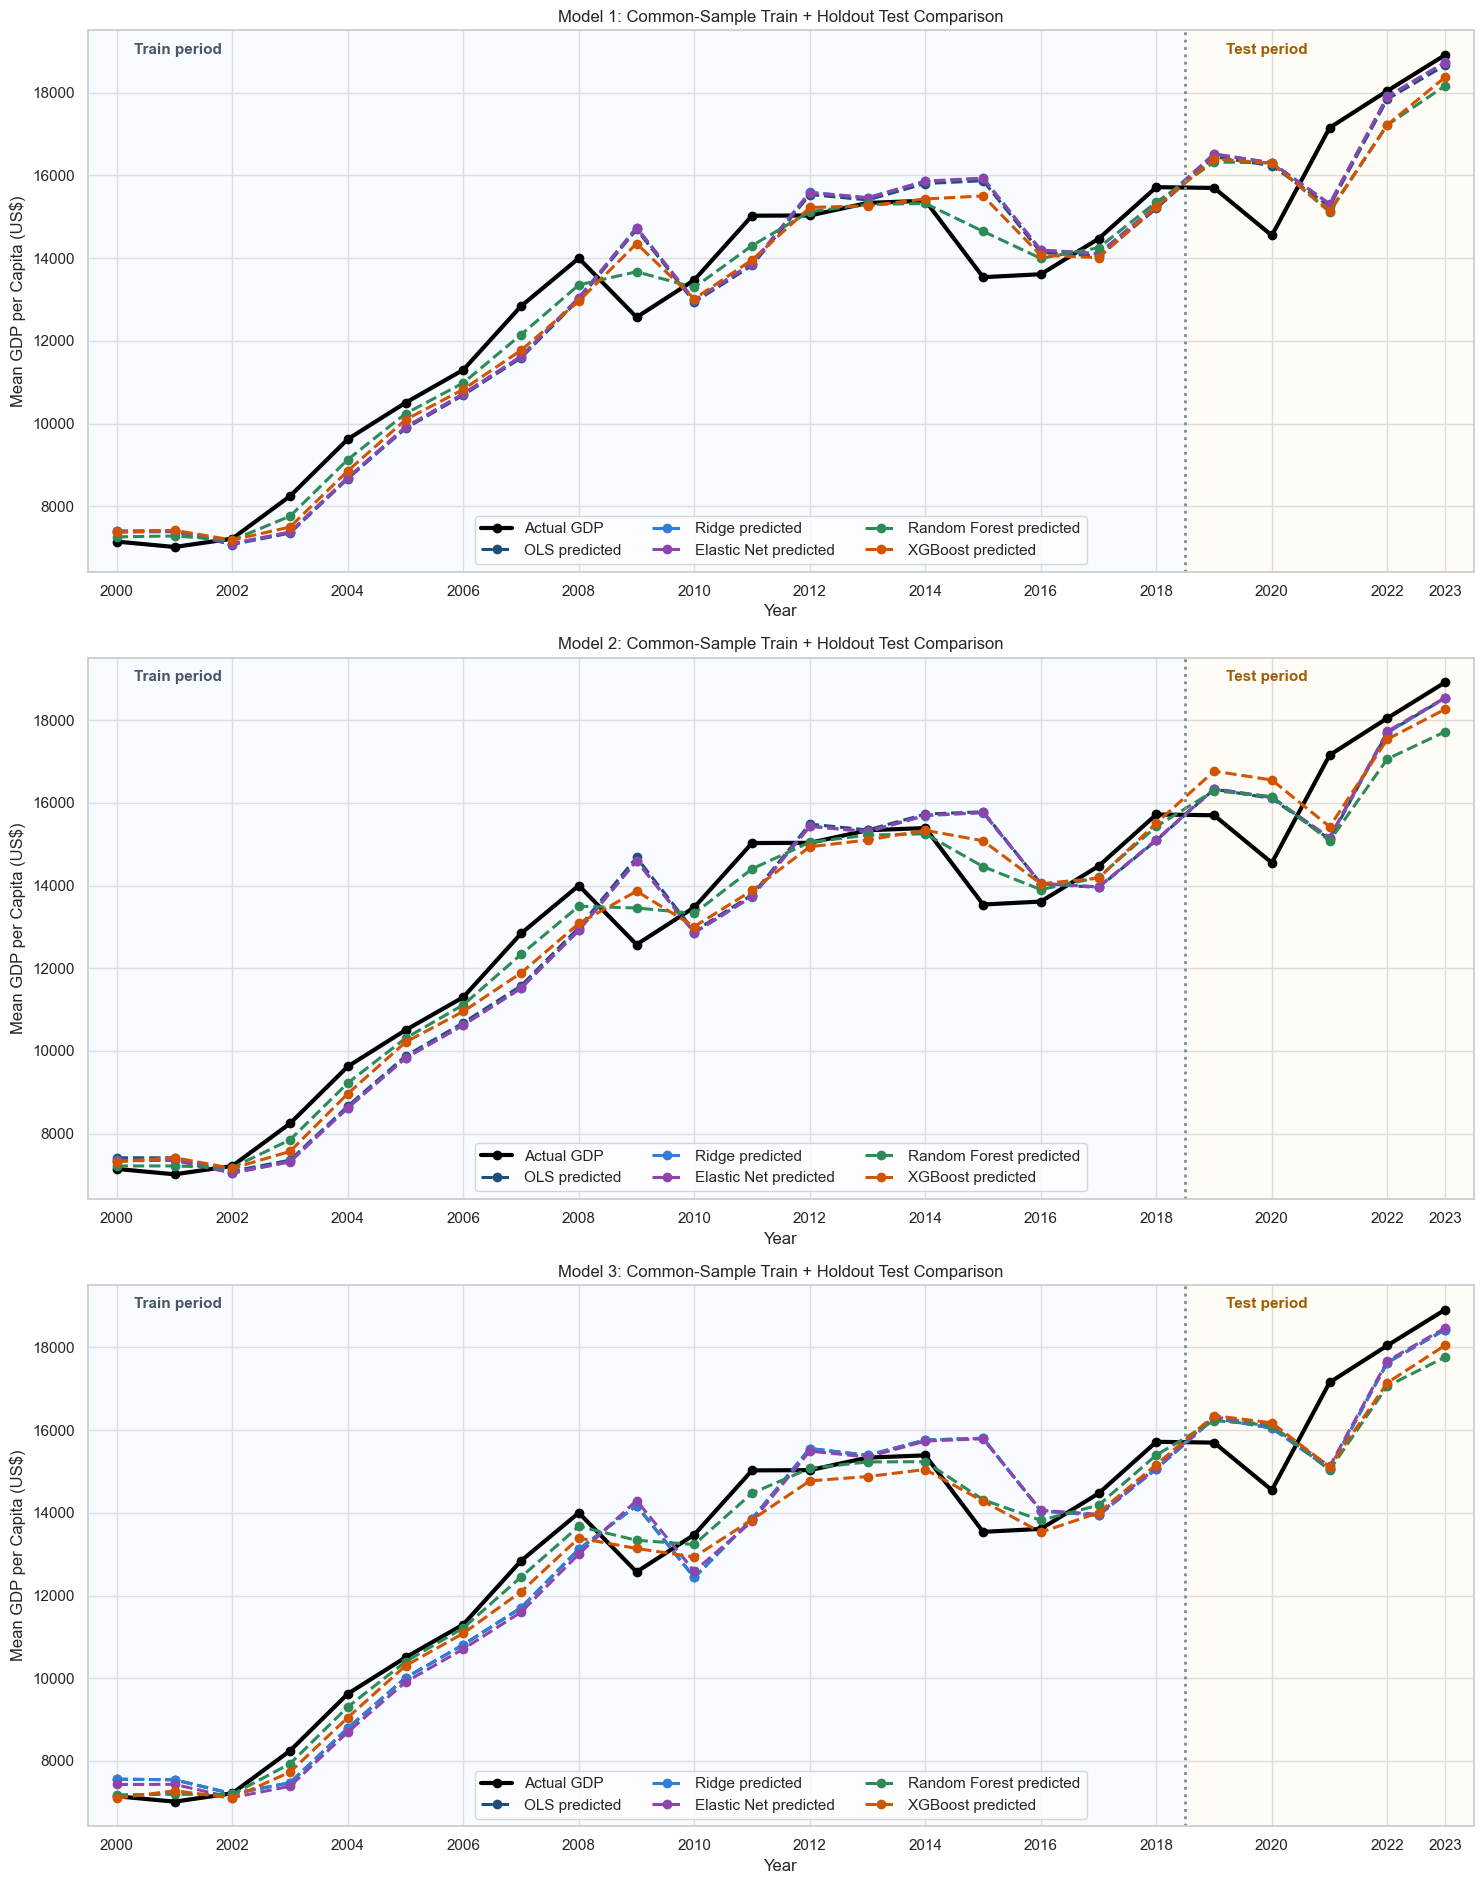

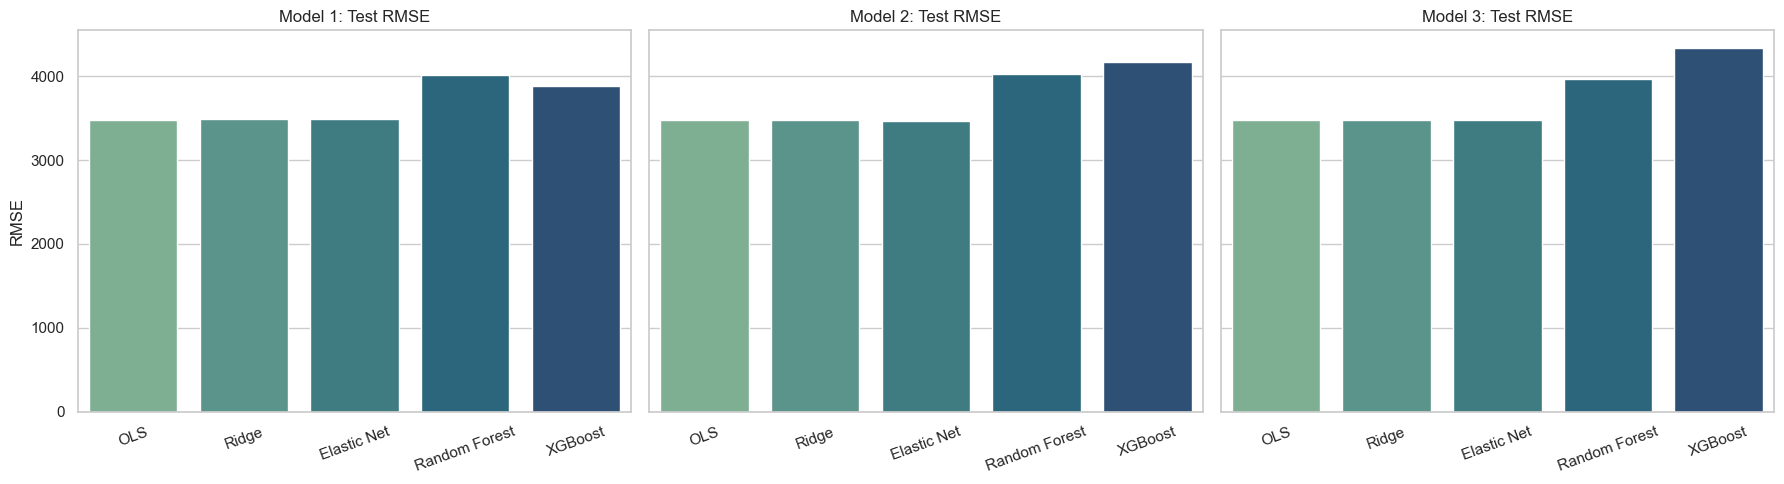

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(15, 19), sharex=False)

color_map = {
    "Actual": "black",
    "OLS": "#1f4e79",
    "Ridge": "#2f7ed8",
    "Elastic Net": "#8e44ad",
    "Random Forest": "#2e8b57",
    "XGBoost": "#d35400",
}

for ax, spec_label in zip(axes, SPEC_ORDER):
    plot_df = context_summary_df[context_summary_df["spec"] == spec_label].copy()
    test_years = sorted(
        plot_df.loc[plot_df["segment"].str.contains("test"), "plot_year"].unique()
    )
    all_years = sorted(plot_df["plot_year"].unique())
    plot_start_year = min(all_years)
    test_start_year = min(test_years)
    test_end_year = max(test_years)

    actual_df = plot_df[plot_df["algorithm"] == "Actual"].sort_values("plot_year")
    ax.plot(
        actual_df["plot_year"],
        actual_df["mean_gdp"],
        marker="o",
        linewidth=3,
        color=color_map["Actual"],
        label="Actual GDP",
    )

    for algorithm in ALGORITHM_ORDER:
        algo_df = plot_df[plot_df["algorithm"] == algorithm].sort_values("plot_year")
        ax.plot(
            algo_df["plot_year"],
            algo_df["mean_gdp"],
            marker="o",
            linewidth=2.2,
            linestyle="--",
            color=color_map[algorithm],
            label=f"{algorithm} predicted",
        )

    ax.axvspan(plot_start_year - 0.5, test_start_year - 0.5, color="#eef4ff", alpha=0.45)
    ax.axvspan(test_start_year - 0.5, test_end_year + 0.5, color="#fff7e8", alpha=0.38)
    ax.axvline(test_start_year - 0.5, color="#7f8c8d", linestyle=":", linewidth=2)
    ax.text(
        plot_start_year + 0.3,
        ax.get_ylim()[1] * 0.985,
        "Train period",
        fontsize=11,
        color="#4a5568",
        va="top",
        fontweight="bold",
    )
    ax.text(
        test_start_year + 0.2,
        ax.get_ylim()[1] * 0.985,
        "Test period",
        fontsize=11,
        color="#a15c00",
        va="top",
        fontweight="bold",
    )

    tick_years = list(range(plot_start_year, test_end_year + 1, 2))
    if test_end_year not in tick_years:
        tick_years.append(test_end_year)

    ax.set_xticks(sorted(set(int(x) for x in tick_years)))
    ax.set_xlim(plot_start_year - 0.5, test_end_year + 0.5)
    ax.set_title(f"{spec_label}: Common-Sample Train + Holdout Test Comparison")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean GDP per Capita (US$)")
    ax.legend(ncol=3)

plt.tight_layout()
if "ipykernel" in sys.modules:
    plt.show()
else:
    plt.close()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

rmse_palette = sns.color_palette("crest", n_colors=len(ALGORITHM_ORDER))

for ax, spec_label in zip(axes, SPEC_ORDER):
    bar_df = common_metrics_df[common_metrics_df["spec"] == spec_label].copy()
    sns.barplot(
        data=bar_df,
        x="algorithm",
        y="RMSE",
        hue="algorithm",
        dodge=False,
        legend=False,
        palette=rmse_palette,
        ax=ax,
    )
    ax.set_title(f"{spec_label}: Test RMSE")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
if "ipykernel" in sys.modules:
    plt.show()
else:
    plt.close()